# ⚡ Indian Power Grid Analysis
EDA · Linear Regression · SVD · PCA

Dataset: Mukherjee, Debanjan; Kalita, Karuna; Kumar, Subhash (2024), “Electricity Demand, Solar and Wind Generation Data (2021-2023) of India at 1-hour interval”, Mendeley Data, V1, doi: 10.17632/y58jknpgs8.1




### Importing Required modules : 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA,TruncatedSVD
print("Setup completed")

Setup completed


## EDA:

### Loading Datasets:

In [2]:
df=pd.read_csv("energy_combined.csv")

### Data Understanding

In [3]:
df.shape

(4062240, 16)

In [4]:
df.head()

,Date&Time,TOTAL_THM_ONLY|P,TOTAL_NLDC_HYD|P,TOTAL_NLDC_GAS|P,TOTAL_NLDC_NPC|P,ALL_INDIA_WIND|P,ALL_IND_SOLAR|P,Solar,Solar+Wind,Total,NLDC_DEMAND|P,INTRA_SYSTEM_INTERTIA|P,ER_Total_Inertia|P,SYS_IN|P,SPARE 05,Wind+Solar
0,2022-04-01 00:00:00,150423.968750,19229.156250,3928.218750,4755.516602,6728.186523,44.764320,44.764320,6772.950844,185109.811195,183308.343750,3.393723,3.621986,3.353905,16.141479,NaN
1,2022-04-01 00:05:00,150783.531250,18075.972656,4004.542236,4758.379395,6804.833496,44.597828,44.597828,6849.431324,184471.856861,182561.500000,3.393723,3.621986,3.362124,16.141479,NaN
2,2022-04-01 00:10:00,151152.453125,18068.656250,3948.116699,4754.988770,6844.566406,-9.911819,0.000000,6844.566406,184768.781250,182791.015625,3.379867,3.621986,3.370395,16.141479,NaN
3,2022-04-01 00:15:00,151289.015625,18149.667969,3964.137695,4745.046387,6909.796875,-9.991449,0.000000,6909.796875,185057.664551,182987.828125,3.381109,3.621986,3.346536,16.141479,NaN
4,2022-04-01 00:20:00,151210.890625,18459.925781,3898.012695,4763.541504,6939.600098,-10.066061,0.000000,6939.600098,185271.970703,183484.171875,3.381109,3.621986,3.346536,16.141479,NaN


In [5]:
df.tail()

,Date&Time,TOTAL_THM_ONLY|P,TOTAL_NLDC_HYD|P,TOTAL_NLDC_GAS|P,TOTAL_NLDC_NPC|P,ALL_INDIA_WIND|P,ALL_IND_SOLAR|P,Solar,Solar+Wind,Total,NLDC_DEMAND|P,INTRA_SYSTEM_INTERTIA|P,ER_Total_Inertia|P,SYS_IN|P,SPARE 05,Wind+Solar
4062235,2023-09-30 23:59:10,144687.734375,22645.843750,3340.951904,6167.801758,9108.978516,66.812729,66.812729,9175.791245,186018.123032,184154.156250,3.3483,3.621986,2.606982,2.103658,NaN
4062236,2023-09-30 23:59:20,144708.953125,22638.560547,3353.915527,6168.792969,9110.550781,68.896751,68.896751,9179.447533,186049.669701,184115.734375,3.3483,3.621986,2.606982,2.103658,NaN
4062237,2023-09-30 23:59:30,144707.937500,22587.972656,3335.038086,6171.265137,9117.301758,68.694595,68.694595,9185.996353,185988.209732,184196.140625,3.3483,3.621986,2.606982,2.103658,NaN
4062238,2023-09-30 23:59:40,144682.484375,22566.507812,3360.060547,6163.781250,9122.521484,65.441582,65.441582,9187.963066,185960.797050,184249.109375,3.3483,3.621986,2.606982,2.103658,NaN
4062239,2023-09-30 23:59:50,144703.125000,22542.074219,3357.859863,6168.752930,9113.937500,65.307312,65.307312,9179.244812,185951.056824,184226.765625,3.3483,3.621986,2.606982,2.103658,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4062240 entries, 0 to 4062239
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Date&Time                str    
 1   TOTAL_THM_ONLY|P         float64
 2   TOTAL_NLDC_HYD|P         float64
 3   TOTAL_NLDC_GAS|P         float64
 4   TOTAL_NLDC_NPC|P         float64
 5   ALL_INDIA_WIND|P         float64
 6   ALL_IND_SOLAR|P          float64
 7   Solar                    float64
 8   Solar+Wind               float64
 9   Total                    float64
 10  NLDC_DEMAND|P            float64
 11  INTRA_SYSTEM_INTERTIA|P  float64
 12  ER_Total_Inertia|P       float64
 13  SYS_IN|P                 float64
 14  SPARE 05                 float64
 15  Wind+Solar               float64
dtypes: float64(15), str(1)
memory usage: 495.9 MB


In [7]:
df.describe()

,TOTAL_THM_ONLY|P,TOTAL_NLDC_HYD|P,TOTAL_NLDC_GAS|P,TOTAL_NLDC_NPC|P,ALL_INDIA_WIND|P,ALL_IND_SOLAR|P,Solar,Solar+Wind,Total,NLDC_DEMAND|P,INTRA_SYSTEM_INTERTIA|P,ER_Total_Inertia|P,SYS_IN|P,SPARE 05,Wind+Solar
count,4.062240e+06,4.062240e+06,4.062240e+06,4.062240e+06,4.062240e+06,4.062240e+06,4.062240e+06,3.552480e+06,4.062240e+06,4.062240e+06,4.062240e+06,4.062240e+06,4.062240e+06,4.062240e+06,509760.000000
mean,1.350083e+05,1.684220e+04,3.088360e+03,5.194456e+03,7.761285e+03,1.130812e+04,1.130999e+04,1.897880e+04,1.792046e+05,1.774893e+05,3.285114e+00,3.556765e+00,2.473728e+00,4.975960e+00,19752.254967
std,1.442091e+04,8.460756e+03,1.388274e+03,5.806269e+02,5.444798e+03,1.449535e+04,1.449388e+04,1.458555e+04,2.247969e+04,2.233359e+04,3.070107e-01,8.224004e-01,3.654816e-01,3.360311e+00,15678.156650
min,0.000000e+00,0.000000e+00,-5.375199e+03,0.000000e+00,0.000000e+00,-1.887314e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.083221e+01,0.000000e+00,0.000000e+00,0.000000
25%,1.251989e+05,9.406965e+03,2.226931e+03,4.821385e+03,3.491851e+03,5.672636e+01,5.672636e+01,6.562611e+03,1.644318e+05,1.628208e+05,3.256833e+00,3.621986e+00,2.239712e+00,2.105926e+00,6092.275484
50%,1.374596e+05,1.564657e+04,2.575421e+03,5.257159e+03,6.053712e+03,1.014763e+03,1.014763e+03,1.404591e+04,1.816985e+05,1.799723e+05,3.313066e+00,3.621986e+00,2.518308e+00,3.219813e+00,13608.822849
75%,1.458730e+05,2.345800e+04,3.409563e+03,5.597765e+03,1.105900e+04,2.484925e+04,2.484925e+04,3.125630e+04,1.957701e+05,1.940535e+05,3.367546e+00,3.621986e+00,2.738812e+00,9.206159e+00,34736.299988
max,1.664195e+05,6.018360e+04,1.260984e+04,3.839745e+04,4.038013e+04,4.442352e+04,4.442352e+04,6.420426e+04,2.510247e+05,4.666739e+05,6.500000e+00,7.766609e+02,3.760200e+00,2.165496e+01,59418.394531


Things noted, and its solution:
1. DateTime Column needs to change to Datetime format, and need to set it as index
2. Electricity from Gas and Solar has negative value, data needs clipping since power production cant be negative probablly sensor related erorrs.
3. Solar+wind and Wind+Solar seems to be related and needs checking.
4. 2 Solar production columns, needs checking
5. Need to confirm what Column Total represents, if it sum of all productions, or anything else

 ### Cleaning: 


#### Date and Time:

Formatting Date&Time Data to datetime :

In [8]:
df['Date&Time'] = pd.to_datetime(df['Date&Time'], format='%Y-%m-%d %H:%M:%S')
df = df.sort_values('Date&Time')

Checking if all date time is in uniform and equal distance:

In [9]:
df.groupby([df['Date&Time'].dt.year, df['Date&Time'].dt.month]).size()

Date&Time  Date&Time
2021       9              8640
           10             8928
           11             8640
           12             8928
2022       1              8928
           2              8064
           3              8928
           4              8640
           5              8928
           6              8640
           7              8928
           8              8928
           9              8640
           10           267840
           11           259200
           12           267840
2023       1            267840
           2            241920
           3            267840
           4            259200
           5            267840
           6            259200
           7            267840
           8            267840
           9            259200
           10           267840
           11           259200
           12           267840
dtype: int64

Making datetime as index and resampling with equal interal (5 mins):

In [10]:
df = df.set_index('Date&Time').resample('5min').mean()

In [11]:
df.groupby([df.index.year, df.index.month]).size()

Date&Time  Date&Time
2021       9            8640
           10           8928
           11           8640
           12           8928
2022       1            8928
           2            8064
           3            8928
           4            8640
           5            8928
           6            8640
           7            8928
           8            8928
           9            8640
           10           8928
           11           8640
           12           8928
2023       1            8928
           2            8064
           3            8928
           4            8640
           5            8928
           6            8640
           7            8928
           8            8928
           9            8640
           10           8928
           11           8640
           12           8928
dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 245376 entries, 2021-09-01 00:00:00 to 2023-12-31 23:55:00
Freq: 5min
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   TOTAL_THM_ONLY|P         245376 non-null  float64
 1   TOTAL_NLDC_HYD|P         245376 non-null  float64
 2   TOTAL_NLDC_GAS|P         245376 non-null  float64
 3   TOTAL_NLDC_NPC|P         245376 non-null  float64
 4   ALL_INDIA_WIND|P         245376 non-null  float64
 5   ALL_IND_SOLAR|P          245376 non-null  float64
 6   Solar                    245376 non-null  float64
 7   Solar+Wind               228384 non-null  float64
 8   Total                    245376 non-null  float64
 9   NLDC_DEMAND|P            245376 non-null  float64
 10  INTRA_SYSTEM_INTERTIA|P  245376 non-null  float64
 11  ER_Total_Inertia|P       245376 non-null  float64
 12  SYS_IN|P                 245376 non-null  float64
 13  SPARE 05                 

#### Solar wind

In [13]:
#merging solar+wind and wind +solar
df['Solar+Wind'] = df['Solar+Wind'].combine_first(df['Wind+Solar'])
df=df.drop(columns=['Wind+Solar'])

In [14]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 245376 entries, 2021-09-01 00:00:00 to 2023-12-31 23:55:00
Freq: 5min
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   TOTAL_THM_ONLY|P         245376 non-null  float64
 1   TOTAL_NLDC_HYD|P         245376 non-null  float64
 2   TOTAL_NLDC_GAS|P         245376 non-null  float64
 3   TOTAL_NLDC_NPC|P         245376 non-null  float64
 4   ALL_INDIA_WIND|P         245376 non-null  float64
 5   ALL_IND_SOLAR|P          245376 non-null  float64
 6   Solar                    245376 non-null  float64
 7   Solar+Wind               245376 non-null  float64
 8   Total                    245376 non-null  float64
 9   NLDC_DEMAND|P            245376 non-null  float64
 10  INTRA_SYSTEM_INTERTIA|P  245376 non-null  float64
 11  ER_Total_Inertia|P       245376 non-null  float64
 12  SYS_IN|P                 245376 non-null  float64
 13  SPARE 05                 

#### dropping duplicate data after comfirming:


In [15]:
# There is 2 solar columns, Solar is probably clipped version of ALL_IND_SOLAR|P.
clipped_check = (df["ALL_IND_SOLAR|P"].clip(lower=0)).corr(df["Solar"])
print(clipped_check)




0.9999999258936323


In [16]:
#correlation value suggest data is similar, keeping ALL_IND_SOLAR|P as it seems to contain original data
df=df.drop(columns="Solar")


#### Renaming all the existing Columns:




In [17]:
rename_map = {
    "TOTAL_THM_ONLY|P": "thermal_mw",
    "TOTAL_NLDC_HYD|P": "hydro_mw",
    "TOTAL_NLDC_GAS|P": "gas_mw",
    "TOTAL_NLDC_NPC|P": "nuclear_mw",
    "ALL_INDIA_WIND|P": "wind_mw",
    "ALL_IND_SOLAR|P": "solar_mw",
    "Solar+Wind": "solar_wind_mw",
    "Total": "total_generation_mw",
    "NLDC_DEMAND|P": "nldc_demand_mw",
    "INTRA_SYSTEM_INTERTIA|P": "intra_system_inertia",
    "ER_Total_Inertia|P": "er_total_inertia",
    "SYS_IN|P": "sys_in",
    "SPARE 05": "spare_05"
}

df = df.rename(columns=rename_map)
print(df.columns)

Index(['thermal_mw', 'hydro_mw', 'gas_mw', 'nuclear_mw', 'wind_mw', 'solar_mw',
       'solar_wind_mw', 'total_generation_mw', 'nldc_demand_mw',
       'intra_system_inertia', 'er_total_inertia', 'sys_in', 'spare_05'],
      dtype='str')


#### Clipping Data:

In [18]:
df["solar_mw"] = df["solar_mw"].clip(lower=0)
df["gas_mw"] = df["gas_mw"].clip(lower=0)

#### Checking for null Values: 


In [19]:
df.isnull().sum()

thermal_mw              0
hydro_mw                0
gas_mw                  0
nuclear_mw              0
wind_mw                 0
solar_mw                0
solar_wind_mw           0
total_generation_mw     0
nldc_demand_mw          0
intra_system_inertia    0
er_total_inertia        0
sys_in                  0
spare_05                0
dtype: int64

### Feature Engineering


#### 1) Total Generation from Production Sources:


In [20]:
# Make total generation exactly equal to sum of all production sources
production_cols = ["thermal_mw", "hydro_mw", "gas_mw", "nuclear_mw", "wind_mw", "solar_mw"]
df["total_generation_mw"] = df[production_cols].sum(axis=1)
df[["total_generation_mw"] + production_cols].head()


,total_generation_mw,thermal_mw,hydro_mw,gas_mw,nuclear_mw,wind_mw,solar_mw
Date&Time,,,,,,,
2021-09-01 00:00:00,163181.007080,117296.390625,29213.222656,5310.232422,3521.782959,7839.378418,0.0
2021-09-01 00:05:00,162550.107422,117527.460938,28562.003906,5079.435547,3525.912109,7855.294922,0.0
2021-09-01 00:10:00,163016.411621,117849.773438,28794.048828,5002.250488,3509.998535,7860.340332,0.0
2021-09-01 00:15:00,163609.458984,118723.609375,28577.851562,4908.347656,3516.291504,7883.358887,0.0
2021-09-01 00:20:00,162515.720947,117994.101562,28159.519531,4966.328125,3506.946045,7888.825684,0.0



#### 2) Peak-Hour Flag:

In [21]:
# peak-hour feature: 6:00 PM to before 10:00 PM (18:00-21:59)
df["is_peak_hour"] = ((df.index.hour >= 18) & (df.index.hour < 22)).astype("int16")

#### 3) Hour of the day:

In [22]:
df["hour"]=df.index.hour

#### 4) Day of the week:

In [23]:
df["day_of_week"] = df.index.dayofweek

#### 5) Month of the Year:

In [24]:
df["month"]=df.index.month

##### 6) Season of the year: 

In [25]:
def indian_season(month):
    if month in [3, 4, 5]:   return "summer"
    if month in [6, 7, 8, 9]: return "monsoon"
    if month in [10, 11]:     return "post_monsoon"
    return "winter"

df["season"] = df.index.month.map(indian_season)
df = pd.get_dummies(df, columns=["season"], drop_first=True, dtype="int16")

## Visualizations:

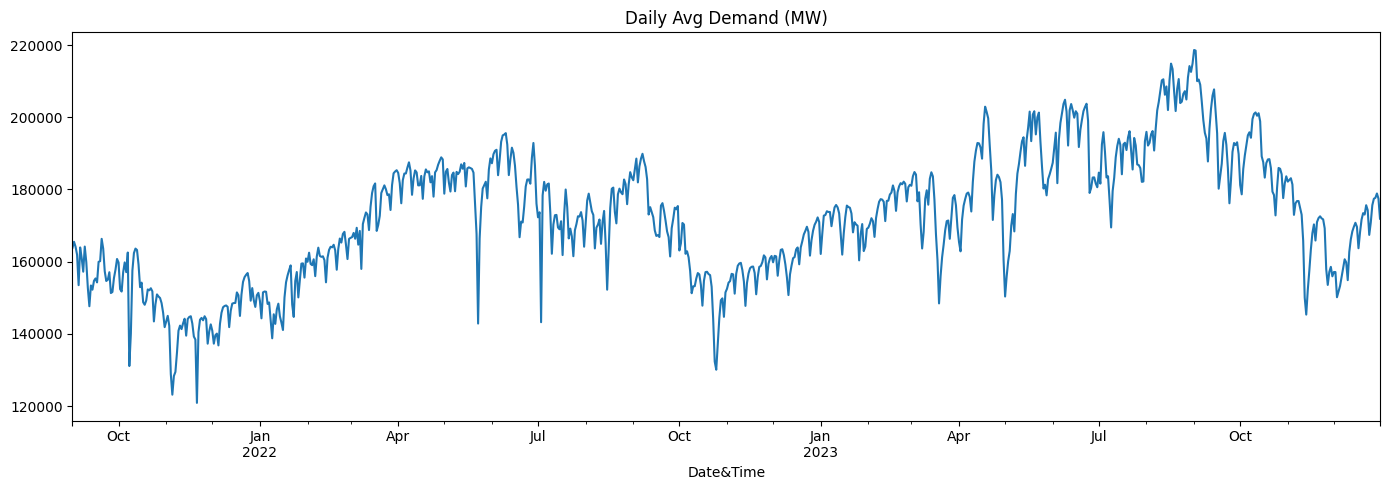

In [26]:
plt.figure(figsize=(14, 5))
df["nldc_demand_mw"].resample("D").mean().plot(title="Daily Avg Demand (MW)")
plt.tight_layout()
plt.show()

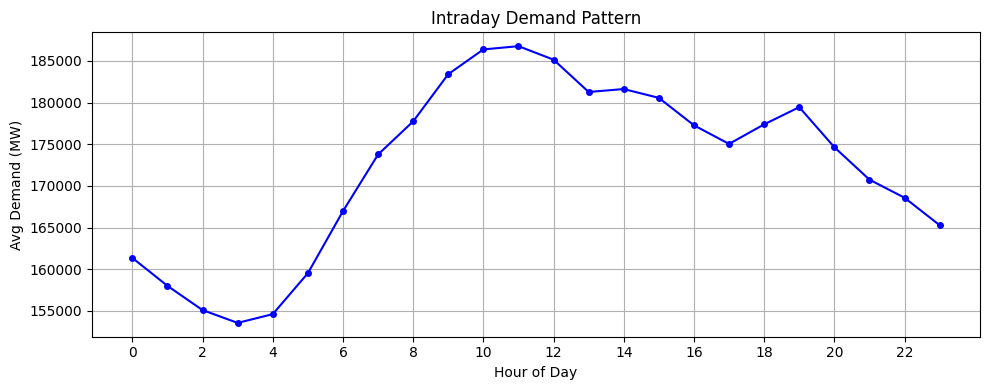

In [27]:
# Intraday Demand Pattern
hourly = df.groupby(df.index.hour)["nldc_demand_mw"].mean()
plt.figure(figsize=(10, 4))
plt.plot(hourly.index, hourly.values, 'b-o', markersize=4)
plt.xlabel("Hour of Day")
plt.ylabel("Avg Demand (MW)")
plt.title("Intraday Demand Pattern")
plt.xticks(range(0, 24, 2))
plt.grid(True)
plt.tight_layout()
plt.show()

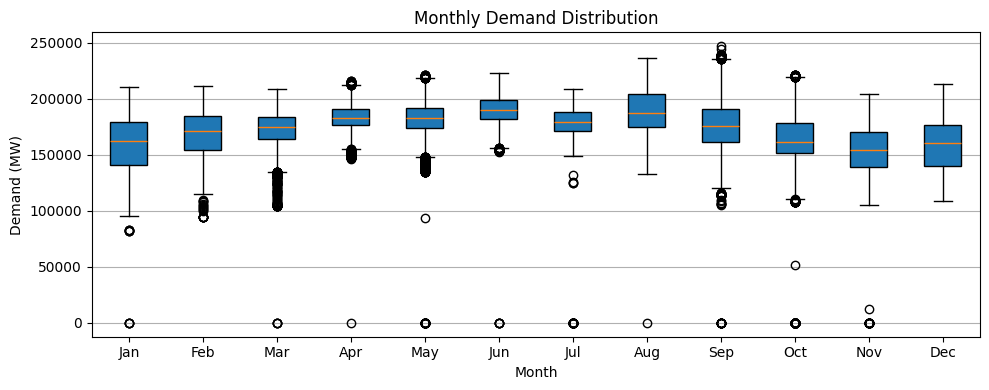

In [28]:
# Monthly Demand Distribution
monthly_data = [df[df.index.month == m]["nldc_demand_mw"].values for m in range(1, 13)]
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(10, 4))
plt.boxplot(monthly_data, tick_labels=months, patch_artist=True)
plt.xlabel("Month")
plt.ylabel("Demand (MW)")
plt.title("Monthly Demand Distribution")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

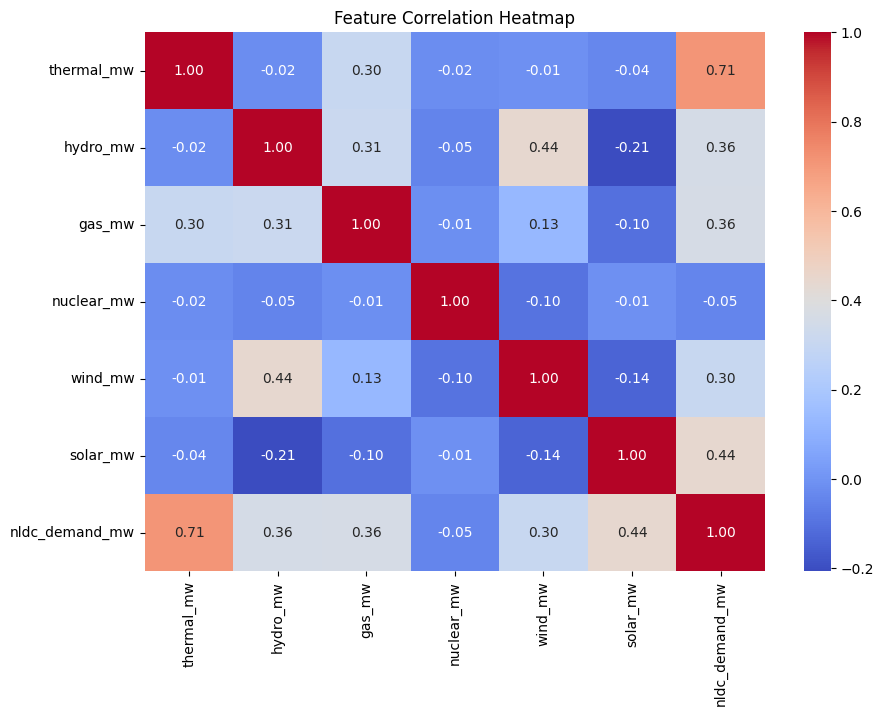

In [29]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
numeric_cols = ["thermal_mw", "hydro_mw", "gas_mw", "nuclear_mw", "wind_mw", "solar_mw", "nldc_demand_mw"]
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

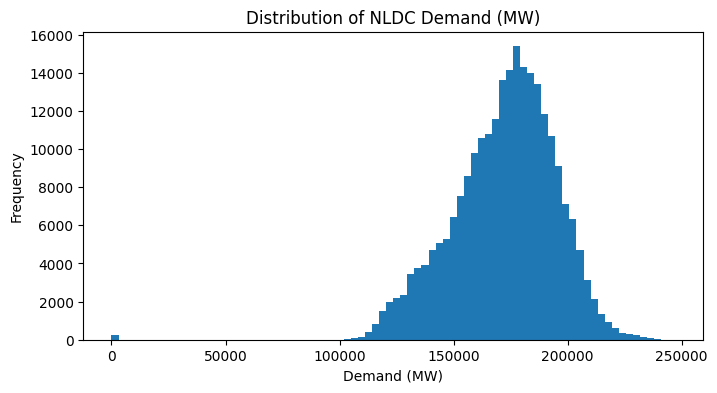

In [30]:
# Distribution of demand
plt.figure(figsize=(8, 4))
df["nldc_demand_mw"].plot(kind="hist", bins=80, title="Distribution of NLDC Demand (MW)")
plt.xlabel("Demand (MW)")
plt.show()

## Linear Regression Analysis

Model target: `nldc_demand_mw` using all available numeric predictors after feature engineering.


In [31]:
features = ['thermal_mw', 'hydro_mw', 'gas_mw', 'nuclear_mw',
            'wind_mw', 'solar_mw', 'is_peak_hour', 'hour', 'month', 'day_of_week',
    'season_post_monsoon', 'season_summer', 'season_winter']
X = df[features]
y = df['nldc_demand_mw']

In [32]:
# --- Temporal split ---
cutoff = int(len(df) * 0.8)
X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]

In [33]:
# Fit model using sklearn
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [35]:
# Metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\n--- Linear Regression Results ---")
print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"Test R²: {test_r2:.4f}, RMSE: {test_rmse:.2f}")
print("Coefficients:", dict(zip(features, model.coef_)))
print("Intercept:", model.intercept_)


--- Linear Regression Results ---
Train R²: 0.9920, RMSE: 1917.36
Test R²: 0.9931, RMSE: 1824.24
Coefficients: {'thermal_mw': np.float64(0.9905532419358665), 'hydro_mw': np.float64(0.9716544703503456), 'gas_mw': np.float64(1.028378533091533), 'nuclear_mw': np.float64(0.1988612232881667), 'wind_mw': np.float64(0.9338532940574216), 'solar_mw': np.float64(0.9911069093188546), 'is_peak_hour': np.float64(65.83768350186162), 'hour': np.float64(10.299434063819945), 'month': np.float64(-40.960551400642196), 'day_of_week': np.float64(17.660791594394293), 'season_post_monsoon': np.float64(566.0550862671585), 'season_summer': np.float64(215.0742999037484), 'season_winter': np.float64(699.3018833911358)}
Intercept: 4181.349293000472


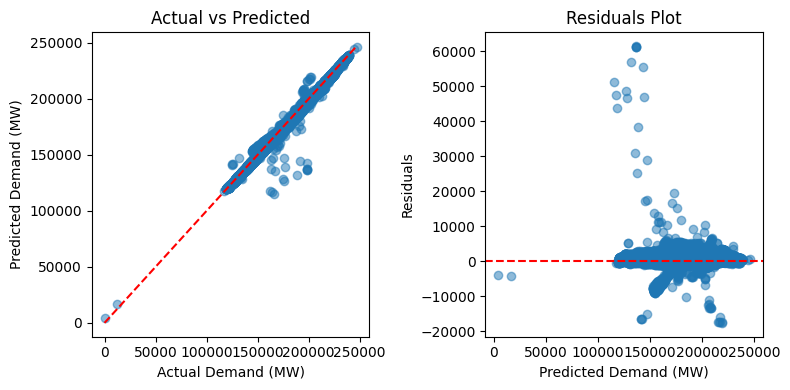

In [36]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Demand (MW)')
plt.ylabel('Predicted Demand (MW)')
plt.title('Actual vs Predicted')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Demand (MW)')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.tight_layout()
plt.show()

## SVD


In [37]:
scaler_svd = StandardScaler()
X_scaled_train_svd = scaler_svd.fit_transform(X_train)
X_scaled_test_svd  = scaler_svd.transform(X_test)

svd = TruncatedSVD(n_components=11, random_state=42)
X_svd_train = svd.fit_transform(X_scaled_train_svd)
X_svd_test  = svd.transform(X_scaled_test_svd)

print("--- SVD Results ---")
print("Explained Variance Ratio:", svd.explained_variance_ratio_)
print("Cumulative:              ", np.cumsum(svd.explained_variance_ratio_))
print("Singular Values:         ", svd.singular_values_)

X_recon_train = svd.inverse_transform(X_svd_train)
recon_error = np.mean((X_scaled_train_svd - X_recon_train) ** 2)
print(f"Reconstruction MSE (scaled): {recon_error:.4f}")

svd_model = LinearRegression()
svd_model.fit(X_svd_train, y_train)
y_pred_svd = svd_model.predict(X_svd_test)
print(f"\nLinear Regression with SVD features - Test R²: {r2_score(y_test, y_pred_svd):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_svd)):.2f}")

--- SVD Results ---
Explained Variance Ratio: [0.18999263 0.1694674  0.11656594 0.09943482 0.08137136 0.07915633
 0.06741342 0.06075667 0.04082289 0.03140322 0.02898466]
Cumulative:               [0.18999263 0.35946003 0.47602597 0.57546079 0.65683215 0.73598848
 0.8034019  0.86415857 0.90498146 0.93638467 0.96536933]
Singular Values:          [696.30610459 657.61984226 545.40316501 503.73378761 455.68802995
 449.44302483 414.76777266 393.75746203 322.76296987 283.08632054
 271.9668184 ]
Reconstruction MSE (scaled): 0.0346

Linear Regression with SVD features - Test R²: 0.9174
Test RMSE: 6306.89


In [38]:
ror = np.mean((X_scaled_train_svd - X_recon_train) ** 2)
print(f"Reconstruction MSE (scaled): {recon_error:.4f}")

svd_model = LinearRegression()
svd_model.fit(X_svd_train, y_train)
y_pred_svd = svd_model.predict(X_svd_test)
print(f"\nLinear Regression with SVD features - Test R²: {r2_score(y_test, y_pred_svd):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_svd)):.2f}")

Reconstruction MSE (scaled): 0.0346

Linear Regression with SVD features - Test R²: 0.9174
Test RMSE: 6306.89


## PCA



--- PCA Results ---
n_components (for 95% var): 11
Explained Variance Ratio: [0.18999263 0.1694674  0.11656594 0.09943482 0.08137136 0.07915633
 0.06741342 0.06075667 0.04082289 0.03140322 0.02898466]
Cumulative Explained Variance: [0.18999263 0.35946003 0.47602597 0.57546079 0.65683215 0.73598848
 0.8034019  0.86415857 0.90498146 0.93638467 0.96536933]


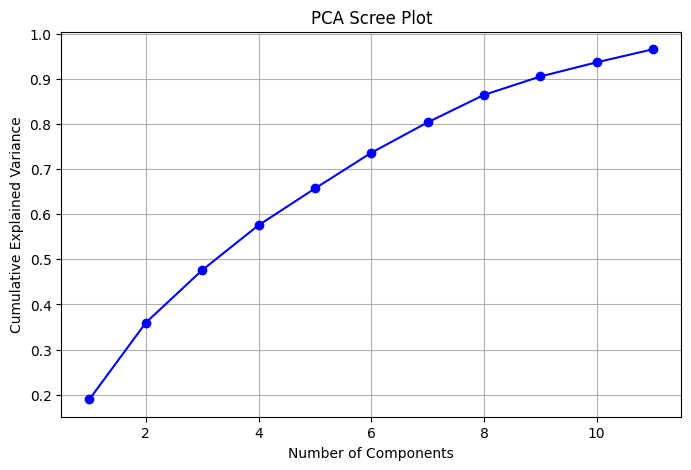

In [39]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)  # Retain 95% variance
X_pca_train = pca.fit_transform(X_scaled_train)
X_pca_test = pca.transform(X_scaled_test)

print("\n--- PCA Results ---")
print(f"n_components (for 95% var): {pca.n_components_}")
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", np.cumsum(pca.explained_variance_ratio_))

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.grid(True)
plt.show()

PCA Component Loadings:
                       PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8  \
thermal_mw          -0.472  0.190  0.079 -0.167 -0.128  0.014 -0.000  0.071   
hydro_mw             0.268  0.474 -0.072  0.160  0.042 -0.057  0.192 -0.014   
gas_mw              -0.056  0.320 -0.063 -0.328 -0.329 -0.001  0.125  0.756   
nuclear_mw           0.096 -0.140  0.227 -0.217 -0.166  0.447  0.773 -0.211   
wind_mw             -0.026  0.375 -0.237  0.518  0.071  0.024  0.250 -0.014   
solar_mw            -0.092 -0.253 -0.210 -0.214  0.604 -0.346  0.346  0.200   
is_peak_hour         0.009  0.403  0.505 -0.087  0.069  0.047 -0.182 -0.203   
hour                -0.011  0.306  0.441 -0.219  0.485 -0.193  0.081 -0.005   
month                0.529  0.033 -0.054 -0.073  0.000 -0.065 -0.046  0.085   
day_of_week          0.025 -0.045  0.020  0.144  0.463  0.757 -0.213  0.360   
season_post_monsoon  0.460 -0.085 -0.019 -0.434 -0.047  0.050 -0.243 -0.047   
season_summer       -0.409  

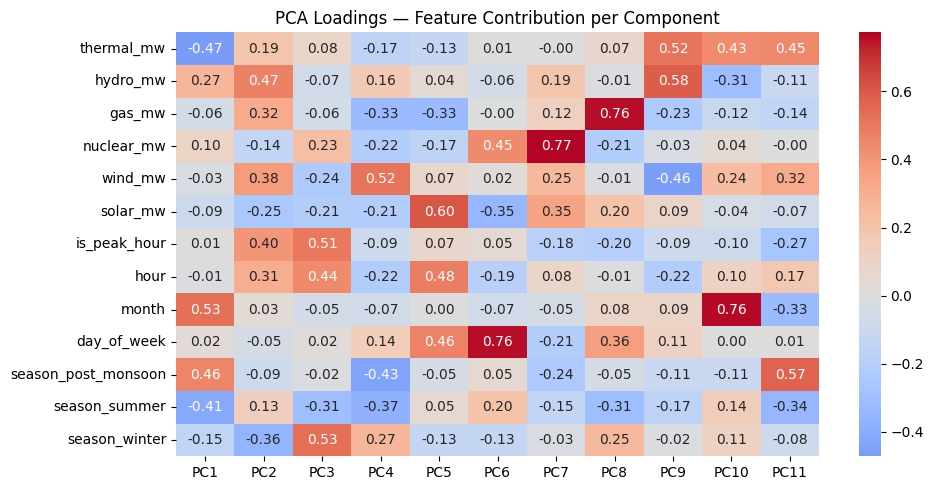

In [40]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("PCA Component Loadings:")
print(loadings.round(3))

plt.figure(figsize=(10, 5))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("PCA Loadings — Feature Contribution per Component")
plt.tight_layout()
plt.show()

PCA

In [41]:
pca_model = LinearRegression()
pca_model.fit(X_pca_train, y_train)
y_pred_pca = pca_model.predict(X_pca_test)
pca_r2 = r2_score(y_test, y_pred_pca)
print(f"Linear Regression with PCA features - Test R²: {pca_r2:.4f}")

Linear Regression with PCA features - Test R²: 0.9174
